# Interleaved Multimodal Data — Quickstart

This notebook walks through the NeMo Curator interleaved multimodal pipeline:

1. **Read** a WebDataset tar shard (MINT-1T format) into row-wise `InterleavedBatch` tasks
2. **Inspect** the interleaved schema — text, images, and metadata in position order
3. **Display** a sample as a rendered document (text + inline images)
4. **Filter** by image aspect ratio
5. **Write** to Parquet

Each sample in MINT-1T is a JSON file paired with a multi-frame TIFF.
The reader extracts individual frames so each image row carries its own single-frame binary.

## Step 1 — Read a WebDataset tar shard

In [1]:
from nemo_curator.stages.interleaved.io.readers.webdataset import WebdatasetReaderStage
from nemo_curator.tasks import FileGroupTask

TAR_PATH = "/datasets/vjawa/MINT-1T-PDF-CC-2024-18-10gb/CC-MAIN-2024-18-shard-0/CC-MAIN-20240412101354-20240412131354-00000.tar"

task = FileGroupTask(task_id="quickstart", dataset_name="mint1t", data=[TAR_PATH], _metadata={})
reader = WebdatasetReaderStage(
    source_id_field="pdf_name",
    materialize_on_read=True,
)
result = reader.process(task)
batch = result[0] if isinstance(result, list) else result

print(f"Samples: {batch.num_items}")
print(f"Total rows: {batch.count()}")
print(f"  text:     {batch.count(modality='text')}")
print(f"  image:    {batch.count(modality='image')}")
print(f"  metadata: {batch.count(modality='metadata')}")

Samples: 56
Total rows: 526
  text:     228
  image:    242
  metadata: 56


## Step 2 — Inspect the interleaved schema

Every row has these reserved columns:

| Column | Description |
|--------|-------------|
| `sample_id` | Unique document identifier |
| `position` | Order within the sample (-1 for metadata) |
| `modality` | `text`, `image`, or `metadata` |
| `content_type` | MIME type |
| `text_content` | Text payload (text rows) |
| `binary_content` | Image bytes (image rows) |
| `source_ref` | JSON locator back to the source tar |
| `metadata_json` | Full original JSON (metadata rows) |
| `materialize_error` | Error message if materialization failed |

Plus any **passthrough fields** from the source JSON (e.g. `url`, `image_metadata`).

In [2]:
import json as _json

import pandas as pd

df = batch.to_pandas()
print(f"All columns: {list(df.columns)}\n")

sample_id = df["sample_id"].iloc[0]
sample = df[df["sample_id"] == sample_id].sort_values("position")

MAX_COL_WIDTH = 60
MAX_META_WIDTH = 80


def _fmt(x: object, max_len: int = MAX_COL_WIDTH) -> str | None:
    if pd.isna(x) or x is None:
        return None
    if isinstance(x, (bytes, bytearray)):
        return f"{len(x):,} bytes"
    s = str(x)
    return s[:max_len] + "..." if len(s) > max_len else s


def _fmt_source_ref(x: object) -> str | None:
    if pd.isna(x) or x is None:
        return None
    try:
        ref = _json.loads(x)
        parts = []
        if ref.get("member"):
            parts.append(ref["member"])
        if ref.get("frame_index") is not None:
            parts.append(f"frame={ref['frame_index']}")
        if ref.get("byte_offset") is not None:
            parts.append(f"offset={ref['byte_offset']}")
        return " | ".join(parts) if parts else "-"
    except (ValueError, TypeError):
        return _fmt(x)


show = sample.copy()
show["text_content"] = show["text_content"].map(_fmt)
show["binary_content"] = show["binary_content"].map(_fmt)
show["metadata_json"] = show["metadata_json"].map(lambda x: _fmt(x, max_len=MAX_META_WIDTH))
show["source_ref"] = show["source_ref"].map(_fmt_source_ref)
show["materialize_error"] = show["materialize_error"].map(_fmt)

pd.set_option("display.max_columns", None)
pd.set_option("display.max_colwidth", MAX_META_WIDTH)
pd.set_option("display.width", 220)

print(f"Sample '{sample_id}' -- {len(sample)} rows\n")
display(show.reset_index(drop=True))

All columns: ['sample_id', 'position', 'modality', 'content_type', 'text_content', 'binary_content', 'source_ref', 'metadata_json', 'materialize_error', 'bff_contained_ngram_count_before_dedupe', 'image_metadata', 'language_id_whole_page_fasttext', 'previous_word_count', 'url']

Sample 'ba16decf89064be49237fb81a59fd3f3' -- 17 rows



,sample_id,position,modality,content_type,text_content,binary_content,source_ref,metadata_json,materialize_error,bff_contained_ngram_count_before_dedupe,image_metadata,language_id_whole_page_fasttext,previous_word_count,url
0,ba16decf89064be49237fb81a59fd3f3,-1,metadata,application/json,None,None,ba16decf89064be49237fb81a59fd3f3.json | offset=512,"{""bff_contained_ngram_count_before_dedupe"": 271, ""image_metadata"": [{""height...",None,271,"[{""height"": 862, ""page"": 0, ""sha256"": ""a58edd0a4c680551e13656c3a3ec3f36586c6...","{""en"": 0.8799859881401062}",7605,https://en.rli.nl/sites/default/files/advice_eletricity_provision_in_the_fac...
1,ba16decf89064be49237fb81a59fd3f3,0,image,image/tiff,None,"339,769 bytes",ba16decf89064be49237fb81a59fd3f3.tiff | frame=0 | offset=57856,None,None,<NA>,<NA>,<NA>,<NA>,<NA>
2,ba16decf89064be49237fb81a59fd3f3,1,text,text/plain,DIGITALISATION FEBRUARY 2018 About the Council for the Envir...,None,ba16decf89064be49237fb81a59fd3f3.json | offset=512,None,None,<NA>,<NA>,<NA>,<NA>,<NA>
3,ba16decf89064be49237fb81a59fd3f3,2,image,image/tiff,None,"411,857 bytes",ba16decf89064be49237fb81a59fd3f3.tiff | frame=1 | offset=57856,None,None,<NA>,<NA>,<NA>,<NA>,<NA>
4,ba16decf89064be49237fb81a59fd3f3,3,text,text/plain,SUMMARY The Netherlands’ electricity system is increasingly ...,None,ba16decf89064be49237fb81a59fd3f3.json | offset=512,None,None,<NA>,<NA>,<NA>,<NA>,<NA>
5,ba16decf89064be49237fb81a59fd3f3,4,image,image/tiff,None,"382,287 bytes",ba16decf89064be49237fb81a59fd3f3.tiff | frame=2 | offset=57856,None,None,<NA>,<NA>,<NA>,<NA>,<NA>
6,ba16decf89064be49237fb81a59fd3f3,5,text,text/plain,INTRODUCTION 1.1 Context The reliability and continuity of e...,None,ba16decf89064be49237fb81a59fd3f3.json | offset=512,None,None,<NA>,<NA>,<NA>,<NA>,<NA>
7,ba16decf89064be49237fb81a59fd3f3,6,image,image/tiff,None,"327,493 bytes",ba16decf89064be49237fb81a59fd3f3.tiff | frame=3 | offset=57856,None,None,<NA>,<NA>,<NA>,<NA>,<NA>
8,ba16decf89064be49237fb81a59fd3f3,7,text,text/plain,ELECTRICITY SYSTEM The coming years will see far-reaching ch...,None,ba16decf89064be49237fb81a59fd3f3.json | offset=512,None,None,<NA>,<NA>,<NA>,<NA>,<NA>
9,ba16decf89064be49237fb81a59fd3f3,8,image,image/tiff,None,"61,401 bytes",ba16decf89064be49237fb81a59fd3f3.tiff | frame=4 | offset=57856,None,None,<NA>,<NA>,<NA>,<NA>,<NA>


## Step 3 — Display as an interleaved document

Render the sample the way a human would read it: metadata at the top, then text and images in position order.


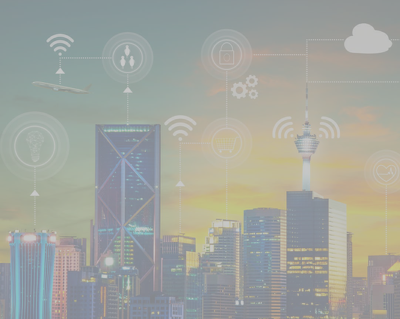
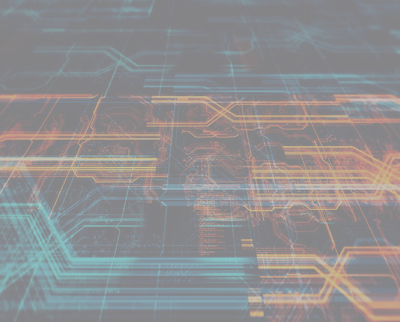
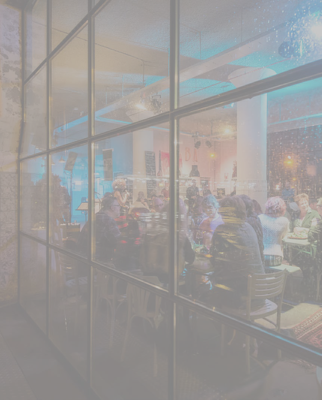
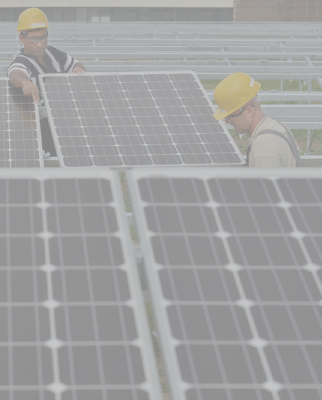
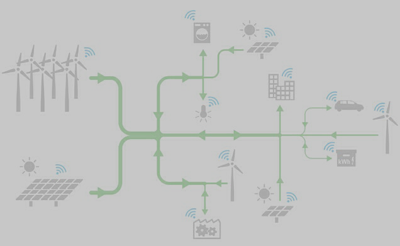
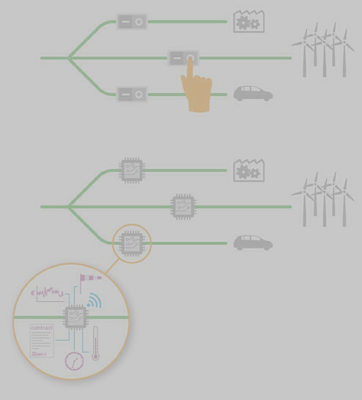
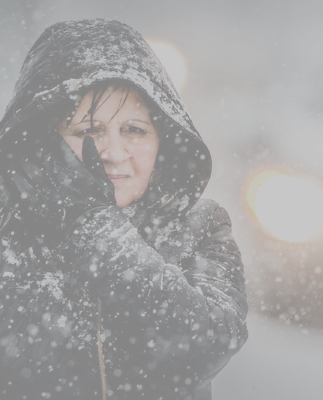
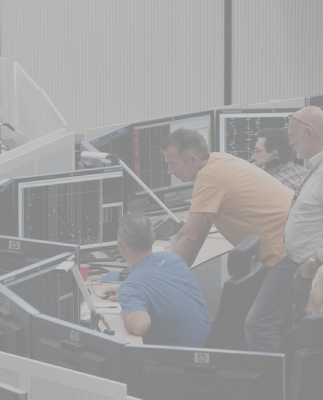
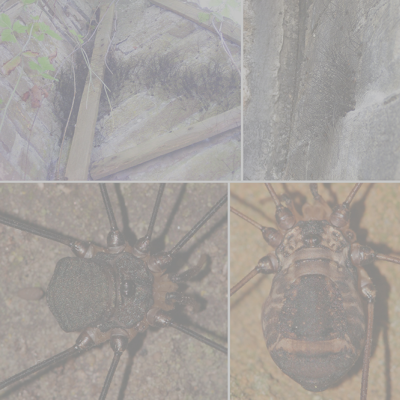
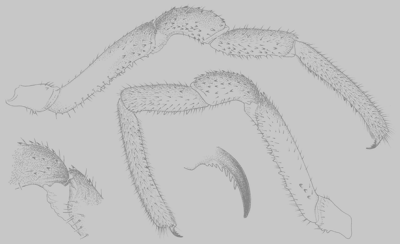

In [3]:
import base64
import json
from io import BytesIO

from IPython.display import HTML
from IPython.display import display as ipy_display
from PIL import Image

URL_TRUNCATE_LEN = 60


def render_interleaved_sample(
    sample_df: pd.DataFrame, sample_id: str, max_text_chars: int = 400, max_img_width: int = 400,
) -> str:
    """Render one InterleavedBatch sample as readable HTML."""
    meta_row = sample_df[sample_df["modality"] == "metadata"]
    content = sample_df[sample_df["modality"] != "metadata"].sort_values("position")

    parts = [
        '<div style="border:2px solid #4a90d9; border-radius:8px; padding:16px; '
        'margin:12px 0; max-width:900px; font-family:sans-serif;">'
    ]

    parts.append(f'<h3 style="margin-top:0; color:#4a90d9;">Sample: <code>{sample_id}</code></h3>')

    if len(meta_row):
        m = meta_row.iloc[0]
        meta_json = json.loads(m["metadata_json"]) if isinstance(m["metadata_json"], str) else {}
        source = meta_json.get("_sample_source", {})
        badges = []
        if source.get("source_shard"):
            badges.append(f"<b>shard:</b> {source['source_shard']}")
        if meta_json.get("url"):
            url = meta_json["url"]
            short = url[:URL_TRUNCATE_LEN] + ("..." if len(url) > URL_TRUNCATE_LEN else "")
            badges.append(f'<b>url:</b> <a href="{url}" target="_blank">{short}</a>')
        for k in ("language_id_whole_page_fasttext", "previous_word_count"):
            if k in meta_json and meta_json[k] is not None:
                badges.append(f"<b>{k}:</b> {meta_json[k]}")
        parts.append(
            '<div style="background:#f0f4f8; padding:8px 12px; border-radius:4px; '
            'margin-bottom:14px; font-size:12px; color:#555;">'
            + " &nbsp;|&nbsp; ".join(badges)
            + "</div>"
        )

    for _, row in content.iterrows():
        pos = int(row["position"])
        mod = row["modality"]

        if mod == "text":
            text = str(row["text_content"]) if not pd.isna(row.get("text_content")) else ""
            snippet = text[:max_text_chars] + "..." if len(text) > max_text_chars else text
            parts.append(
                f'<div style="margin:6px 0; padding:10px; background:#f9fdf9; '
                f'border-left:3px solid #6c6; font-size:13px; line-height:1.5;">'
                f'<span style="color:#aaa; font-size:10px; font-weight:bold;">[{pos}] TEXT</span><br/>'
                f"{snippet}</div>"
            )

        elif mod == "image":
            bc = row["binary_content"]
            if bc is not None and not pd.isna(bc):
                img = Image.open(BytesIO(bc))
                w, h = img.size
                thumb = img.copy()
                thumb.thumbnail((max_img_width, max_img_width))
                buf = BytesIO()
                thumb.save(buf, format="PNG")
                b64 = base64.b64encode(buf.getvalue()).decode()

                ref = json.loads(row["source_ref"]) if isinstance(row["source_ref"], str) else {}
                fi = ref.get("frame_index", "-")
                parts.append(
                    f'<div style="margin:6px 0; padding:10px; background:#fffaf3; '
                    f'border-left:3px solid #f90; text-align:center;">'
                    f'<span style="color:#aaa; font-size:10px; font-weight:bold;">'
                    f"[{pos}] IMAGE &nbsp; frame={fi} &nbsp; {w}x{h} &nbsp; {len(bc):,} bytes</span><br/>"
                    f'<img src="data:image/png;base64,{b64}" '
                    f'style="max-width:{max_img_width}px; margin-top:6px; border:1px solid #e0e0e0; border-radius:4px;"/>'
                    f"</div>"
                )
            else:
                err = row.get("materialize_error")
                msg = str(err) if err and not pd.isna(err) else "binary not available"
                parts.append(
                    f'<div style="margin:6px 0; padding:10px; background:#fff0f0; '
                    f'border-left:3px solid #c00; font-size:13px;">'
                    f'<span style="color:#aaa; font-size:10px;">[{pos}] IMAGE (missing)</span><br/>'
                    f'<span style="color:#c00;">{msg}</span></div>'
                )

    parts.append("</div>")
    return "".join(parts)


html_blocks = []
for sid in df["sample_id"].unique()[:2]:
    html_blocks.append(render_interleaved_sample(df[df["sample_id"] == sid], sid))

ipy_display(HTML("".join(html_blocks)))


## Step 4 — Filter by aspect ratio

`InterleavedAspectRatioFilterStage` opens each image's binary content,
computes the aspect ratio, and drops rows outside the specified range.
Positions are automatically recomputed after filtering.

In [4]:
from nemo_curator.stages.interleaved.stages import InterleavedAspectRatioFilterStage

filter_stage = InterleavedAspectRatioFilterStage(
    min_aspect_ratio=0.5,
    max_aspect_ratio=2.0,
)
filtered_batch = filter_stage.process(batch)

print(f"Before: {batch.count()} rows  ({batch.count(modality='image')} images)")
print(f"After:  {filtered_batch.count()} rows  ({filtered_batch.count(modality='image')} images)")
print(f"Dropped {batch.count() - filtered_batch.count()} rows")

Before: 526 rows  (242 images)
After:  504 rows  (220 images)
Dropped 22 rows



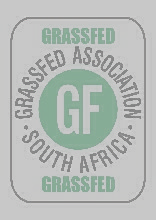

In [5]:
# Show a filtered sample -- positions have been recomputed to close gaps
filtered_df = filtered_batch.to_pandas()
sid = filtered_df["sample_id"].iloc[0]
ipy_display(HTML(render_interleaved_sample(filtered_df[filtered_df["sample_id"] == sid], f"{sid} (filtered)")))


## Step 5 — Write to Parquet

The writer materializes any remaining lazy binary content and writes to Parquet.
The DataFrame index is never included in the output.

In [6]:
import tempfile

import pyarrow.parquet as pq

from nemo_curator.stages.interleaved.io.writers.tabular import InterleavedParquetWriterStage

OUTPUT_DIR = tempfile.mkdtemp(prefix="nemo_curator_quickstart_")

writer = InterleavedParquetWriterStage(
    path=OUTPUT_DIR,
    materialize_on_write=False,   # already materialized at read time
    mode="overwrite",
)
write_result = writer.process(batch)
parquet_path = write_result.data[0]

schema = pq.read_schema(parquet_path)
roundtrip = pd.read_parquet(parquet_path)

print(f"Written to: {parquet_path}")
print(f"Columns: {schema.names}")
print(f"Rows: {len(roundtrip)}")
print(f"Images with binary: {roundtrip[roundtrip['modality'] == 'image']['binary_content'].notna().sum()}")


2026-03-03 05:47:53.970 | INFO     | nemo_curator.utils.file_utils:check_output_mode:335 - Removing output directory /raid/vjawa/tmp/tmp/nemo_curator_quickstart_ls2kmcdv for overwrite mode


2026-03-03 05:47:53.972 | WARNING  | nemo_curator.stages.interleaved.io.writers.base:process:102 - The task does not have source_files in metadata, using UUID for base filename


Written to: /raid/vjawa/tmp/tmp/nemo_curator_quickstart_ls2kmcdv/4b04acf876bd4a2fb4530cd6fff34592.parquet
Columns: ['sample_id', 'position', 'modality', 'content_type', 'text_content', 'binary_content', 'source_ref', 'metadata_json', 'materialize_error', 'bff_contained_ngram_count_before_dedupe', 'image_metadata', 'language_id_whole_page_fasttext', 'previous_word_count', 'url']
Rows: 526
Images with binary: 242



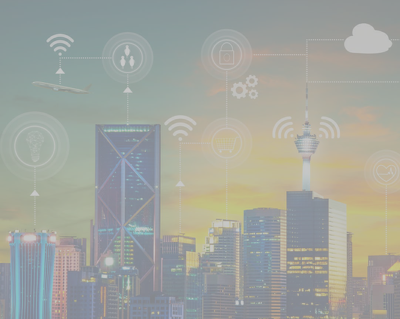
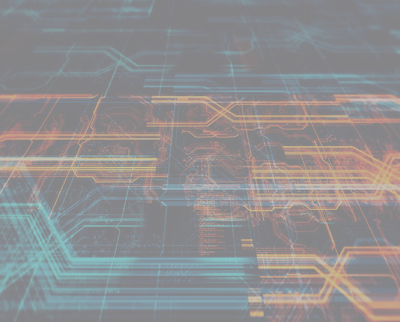
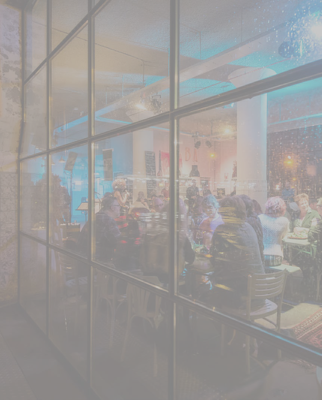
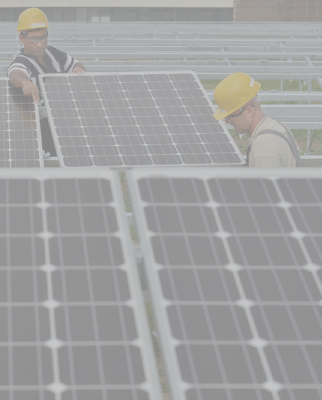
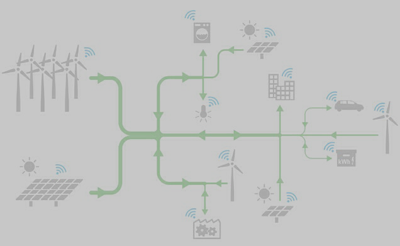
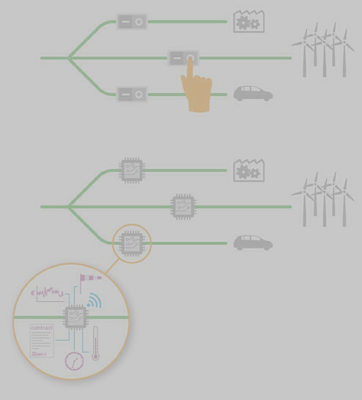
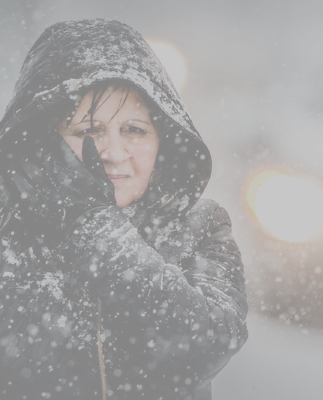
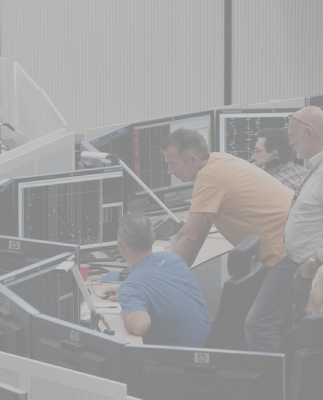

In [7]:
# Verify the roundtrip -- display the same sample from parquet
sid = roundtrip["sample_id"].iloc[0]
ipy_display(HTML(render_interleaved_sample(roundtrip[roundtrip["sample_id"] == sid], f"{sid} (from parquet)")))
